# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:**

Переменная: $x = (x_1, x_2, x_3) \in \mathbb{R}^3$ (размерность 3).

Стандартная форма:
$$
\min_{x \in \mathbb{R}^3} f(x) \quad \text{при} \quad g(x) = 0,
$$
где
$$
f(x) = (x_1 - 1)^2 + (x_2 - 2)^2 + (x_3 - 3)^2, \qquad
g(x) = \begin{pmatrix} x_1 + x_2 + x_3 - 1 \\ x_1 - x_3 \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}.
$$

Ограничений неравенства нет 

**Класс задачи.** Целевая функция $f$ квадратичная, ограничения — линейные равенства. Значит, это **QP** (квадратичное программирование) с ограничениями. Задача **выпуклая**: $f$ строго выпукла (гессиан положительно определён), а допустимое множество — аффинное подпространство (пересечение двух гиперплоскостей), которое всегда выпукло.

**Нахождение точки.** Параметризуем прямую. Из $x_1 - x_3 = 0$ имеем $x_1 = x_3$; пусть $x_1 = x_3 = t$. Тогда из $x_1+x_2+x_3=1$ получаем $x_2 = 1 - 2t$. Тогда параметризированная прямая:
$$
x(t) = (t,\; 1-2t,\; t) = (0, 1, 0) + t\,(1, -2, 1) \qquad 
$$

Подстановка в целевую функцию:
$$
f(x(t)) = (t-1)^2 + (1-2t-2)^2 + (t-3)^2 = (t-1)^2 + (2t+1)^2 + (t-3)^2.
$$

Приравниваем производную к нулю:
$$
\frac{d}{dt} f(x(t)) = 2(t-1) + 4(2t+1) + 2(t-3) = 12t - 4 = 0; \quad t = \frac{1}{3}
$$



Подставляя $t = 1/3$:
$$
x_1 = \frac{1}{3}, \qquad x_2 = 1 - \frac{2}{3} = \frac{1}{3}, \qquad x_3 = \frac{1}{3}.
$$

Ближайшая точка прямой к $(1,2,3)$ — это
$$
x^* = \left(\tfrac{1}{3}, \tfrac{1}{3}, \tfrac{1}{3}\right).
$$

**(б)**

**Ответ:**

Переменная: $x = (x_1, \dots, x_n) \in \mathbb{R}^n$ (размерность $n$) — количества купленных продуктов.

Стандартная форма:
$$
\min_{x \in \mathbb{R}^n} f(x) \quad \text{при} \quad h(x) \ge 0,
$$
где
$$
f(x) = c^\top x = \sum_{j=1}^n c_j x_j, \qquad
h(x) = \begin{pmatrix} Ax - b \\ x \end{pmatrix} \ge 0,
$$
$c \in \mathbb{R}^n$ — цены, $A \in \mathbb{R}^{m \times n}$ — содержание веществ ($A_{ij}$ — количество вещества $i$ в продукте $j$), $b \in \mathbb{R}^m$ — минимальные требования. Равенств нет ($g$ отсутствует). Ограничение $h(x)\ge 0$ распадается на две группы: $Ax - b \ge 0$ (по каждому веществу набрано не меньше нормы) и $x \ge 0$ (нельзя купить отрицательное количество продукта), суммарно $m+n$ неравенств.

**Класс задачи.** Целевая функция $f$ линейна, ограничения тоже линейны (аффинные неравенства). Значит, это **LP** (линейное программирование) с ограничениями. Задача **выпуклая**: линейная функция выпукла (и вогнута) всегда, а допустимое множество — пересечение полупространств (многогранник), т.е. выпуклое множество.

**(в)**

**Ответ:**

Пусть прямоугольник имеет вершины $(\pm a, \pm b)$ со сторонами, параллельными осям, $a, b \ge 0$. Раз прямоугольник **вписан** в единичный круг, все его вершины лежат на окружности: $a^2 + b^2 = 1$. Переменная: $x = (a, b) \in \mathbb{R}^2$ (размерность 2). Площадь прямоугольника = $4ab$, максимизировать её то же самое, что минимизировать $-4ab$.

Стандартная форма:
$$
\min_{x \in \mathbb{R}^2} f(x) \quad \text{при} \quad g(x) = 0,\; h(x) \ge 0,
$$
где
$$
f(x) = -4ab, \qquad
g(x) = a^2 + b^2 - 1, \qquad
h(x) = \begin{pmatrix} a \\ b \end{pmatrix} \ge 0.
$$

**Класс задачи.** Целевая функция квадратичная (билинейная по $a,b$), ограничение $g$ тоже квадратичное, неравенства линейные. Значит, это **QCQP** (квадратичная целевая функция, квадратичное ограничение) с ограничениями.

Задача **не выпуклая** сразу по двум причинам:
1. гессиан $f$ равен $\begin{pmatrix} 0 & -4 \\ -4 & 0 \end{pmatrix}$, собственные значения $\pm4$ — знаконеопределённая матрица, значит $f$ не выпукла;
2. допустимое множество, заданное равенством $a^2+b^2=1$, — это окружность (граница круга), а не сам круг; окружность **не является выпуклым множеством** . 

Оптимум достигается при $a=b=1/\sqrt{2}$ (квадрат), площадь равна $2$.

**(г)**

**Ответ:**

Переменная: $x = (x_1, x_2, x_3) \in \mathbb{R}^3$ (размерность 3) — параметры модели.

Стандартная форма:
$$
\min_{x \in \mathbb{R}^3} f(x),
$$
где
$$
f(x) = \sum_{i=1}^N \bigl(\varphi(t_i; x) - y_i\bigr)^2 = \sum_{i=1}^N \bigl(x_1 \sin(x_2 t_i + x_3) - y_i\bigr)^2.
$$
Ограничений нет ($g$, $h$ отсутствуют).

**Класс задачи.** Модель $\varphi(t;x)$ нелинейна по параметрам $x_2, x_3$ (входят под знак синуса), поэтому это **нелинейный МНК**, класс **NLP** (общая гладкая нелинейная задача), без ограничений.

Задача **не выпуклая**: $\sin(x_2 t + x_3)$ не является ни выпуклой, ни вогнутой функцией, а $f$ — сумма квадратов такой нелинейной по $x$ функции, поэтому $f$ невыпукла.

**(д, бонус)**

**Ответ:**

Функция $\max_i |a_i^\top x - b_i|$ негладкая. Введём одну вспомогательную переменную $s \in \mathbb{R}$, играющую роль общей верхней границы сразу для всех $|a_i^\top x - b_i|$:
$$
s \ge |a_i^\top x - b_i| \quad \forall i \qquad\ -s \le a_i^\top x - b_i \le s \quad \forall i.
$$

Тогда исходная задача эквивалентна гладкой (линейной по ограничениям) задаче с одной дополнительной переменной:
$$
\min_{x,\,s} s \quad \text{при} \quad -s \le a_i^\top x - b_i \le s,\;\; i = 1,\dots,m.
$$


Множество $\{(t, s) : s \ge |t|\}$ — «стакан» над графиком модуля (лекция), задаётся двумя линейными неравенствами $-s \le t \le s$. Минимизация $s$ прижимает точку к его границе, поэтому в решении $s = \max_i |a_i^\top x - b_i|$ ничего не потеряно.

Переменная: $x' = (x, s) \in \mathbb{R}^{n+1}$ (размерность $n+1$).

Стандартная форма:
$$
\min_{x' \in \mathbb{R}^{n+1}} f(x') \quad \text{при} \quad h(x') \ge 0,
$$
где
$$
f(x') = s, \qquad
h(x') = \begin{pmatrix} s - (a_i^\top x - b_i) \\[2pt] s + (a_i^\top x - b_i) \end{pmatrix}_{i=1}^{m} \ge 0 \;\in \mathbb{R}^{2m}
$$
($m$ — число измерений $a_i^\top x - b_i$). Равенств нет.

**Класс задачи.** Целевая функция $f(x') = s$ и все ограничения $h(x')$ линейны по $x'$. Получили **LP** задачу. Задача **выпуклая** (линейная целевая функция + пересечение полупространств — выпуклое множество).

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

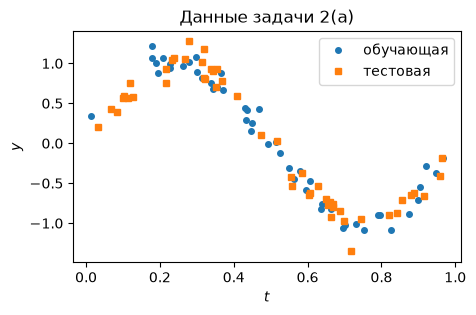

In [2]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

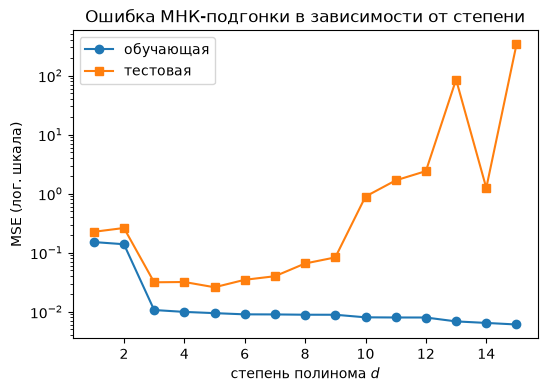

In [3]:
degrees = np.arange(1, 16)
train_mse = np.zeros_like(degrees, dtype=float)
test_mse = np.zeros_like(degrees, dtype=float)

for k, d in enumerate(degrees):
    A_train = np.vander(t_train, d + 1, increasing=True)
    x, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)

    A_test = np.vander(t_test, d + 1, increasing=True)
    train_mse[k] = np.mean((A_train @ x - y_train) ** 2)
    test_mse[k] = np.mean((A_test @ x - y_test) ** 2)

plt.figure(figsize=(6, 4))
plt.semilogy(degrees, train_mse, "o-", label="обучающая")
plt.semilogy(degrees, test_mse, "s-", label="тестовая")
plt.xlabel("степень полинома $d$")
plt.ylabel("MSE (лог. шкала)")
plt.title("Ошибка МНК-подгонки в зависимости от степени")
plt.legend()
plt.show()

**Ответ:** 

Ошибка на обучающей выборке $\mathrm{MSE}_{\text{train}}(d)$ убывает **монотонно** по $d$: увеличивая степень полинома, мы расширяем пространство функций $\{\varphi(t;x) = x_0 + x_1 t + \dots + x_d t^d\}$, и МНК-решение при этом всегда может как минимум сохранить прежнее приближение (положив новые коэффициенты нулевыми), поэтому минимум суммы квадратов невязок на обучающих точках не может возрасти при увеличении $d$.

Ошибка на тестовой выборке $\mathrm{MSE}_{\text{test}}(d)$ ведёт себя **немонотонно**: сначала убывает, пока рост $d$ увеличивает выразительность модели и снижает смещение ($\textit{bias}$) — полином лучше приближает истинную зависимость $\sin(2\pi t)$; затем начинает расти — модель переобучается: она подстраивается под шум конкретной обучающей выборки, и это увеличивает дисперсию предсказаний, что на тестовых точках проявляется как рост ошибки.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [4]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [5]:
def solve_diet(c, A, b):
    return linprog(c, A_ub=-A, b_ub=-b, bounds=[(0, None)] * len(c), method="highs")

res = solve_diet(c, A, b)
x_opt, cost = res.x, res.fun
print("x* =", np.round(x_opt, 6))
print("стоимость =", cost)

resid_ineq = A @ x_opt - b          # невязка Ax - b >= 0
active_nutrients = np.abs(resid_ineq) < 1e-9
active_bounds = np.abs(x_opt) < 1e-9
print("активны Ax>=b:", active_nutrients)
print("активны x>=0:", active_bounds)

b_new = b.copy()
b_new[0] += 1.0
res_new = solve_diet(c, A, b_new)
x_new, cost_new = res_new.x, res_new.fun
print("\nпосле b1 -> b1+1:")
print("x* =", np.round(x_new, 6))
print("стоимость =", cost_new, " (изменение:", cost_new - cost, ")")

resid_new = A @ x_new - b_new
print("активны Ax>=b:", np.abs(resid_new) < 1e-9)
print("активны x>=0:", np.abs(x_new) < 1e-9)

x* = [ 2.  4. -0.  0.]
стоимость = 16.0
активны Ax>=b: [ True  True  True]
активны x>=0: [False False  True  True]

после b1 -> b1+1:
x* = [1.888889 3.555556 0.       0.666667]
стоимость = 17.11111111111111  (изменение: 1.1111111111111107 )
активны Ax>=b: [ True  True  True]
активны x>=0: [False False  True False]


**Ответ:**

Оптимальное решение: $x^* = (2,\ 4,\ 0,\ 0)$, стоимость $c^\top x^* = 16$. Все три ограничения по веществам $Ax \ge b$ активны, а из ограничений $x \ge 0$ активны только $x_3 = 0$ и $x_4 = 0$ — третий и четвёртый продукты в оптимуме не покупаются.

После увеличения требования по первому веществу ($b_1 \to b_1+1$) решение меняется: $x^* = (1.889,\ 3.556,\ 0,\ 0.667)$, стоимость выросла до $17.111$ (на $\Delta = 1.111$). Все три ограничения $Ax \ge b$ по-прежнему активны, но **набор активных ограничений $x\ge0$ изменился**: теперь активно только $x_3=0$, а $x_4$ стал положительным (перестал быть на границе). Ужесточение одного ограничения меняет базис оптимального решения, поэтому активными могут стать другие переменные.